# **TELECOM X - parte 2**

### **Librerías**

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### **Setup**

In [2]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

### **Carga de datos**

Se utilizará el dataset tratado en la primer parte del desafío TelecomX

In [3]:
df = pd.read_csv('../data/raw/df_telecom.csv')

df.head()

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


### **Eliminación de columnas que no aportan al análisis**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   str    
 1   churn              7043 non-null   int64  
 2   gender             7043 non-null   str    
 3   senior_citizen     7043 non-null   int64  
 4   partner            7043 non-null   int64  
 5   dependents         7043 non-null   int64  
 6   tenure             7043 non-null   int64  
 7   phone_service      7043 non-null   int64  
 8   multiple_lines     7043 non-null   int64  
 9   internet_service   7043 non-null   str    
 10  online_security    7043 non-null   int64  
 11  online_backup      7043 non-null   int64  
 12  device_protection  7043 non-null   int64  
 13  tech_support       7043 non-null   int64  
 14  streaming_tv       7043 non-null   int64  
 15  streaming_movies   7043 non-null   int64  
 16  contract           7043 non-null   

In [5]:
df = df.drop(['customer_id'], axis=1)

### **Encoding**

Se utilizará get_dummies para transformar las variables categóricas a numéricas

In [6]:
df_encoded = pd.get_dummies(df, columns=['gender', 'internet_service', 'contract', 'payment_method'], dtype=int)

In [7]:
df_encoded.head()

,churn,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,...,internet_service_DSL,internet_service_Fiber optic,internet_service_No,contract_Month-to-month,contract_One year,contract_Two year,payment_method_Bank transfer (automatic),payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,0,1,0,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,0,1,0,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1


### **Imbalance**

In [8]:
df['churn'].value_counts(normalize=True)

churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

**Hay un leve desbalance en la clase churn**

---

### **Análisis de correlación**

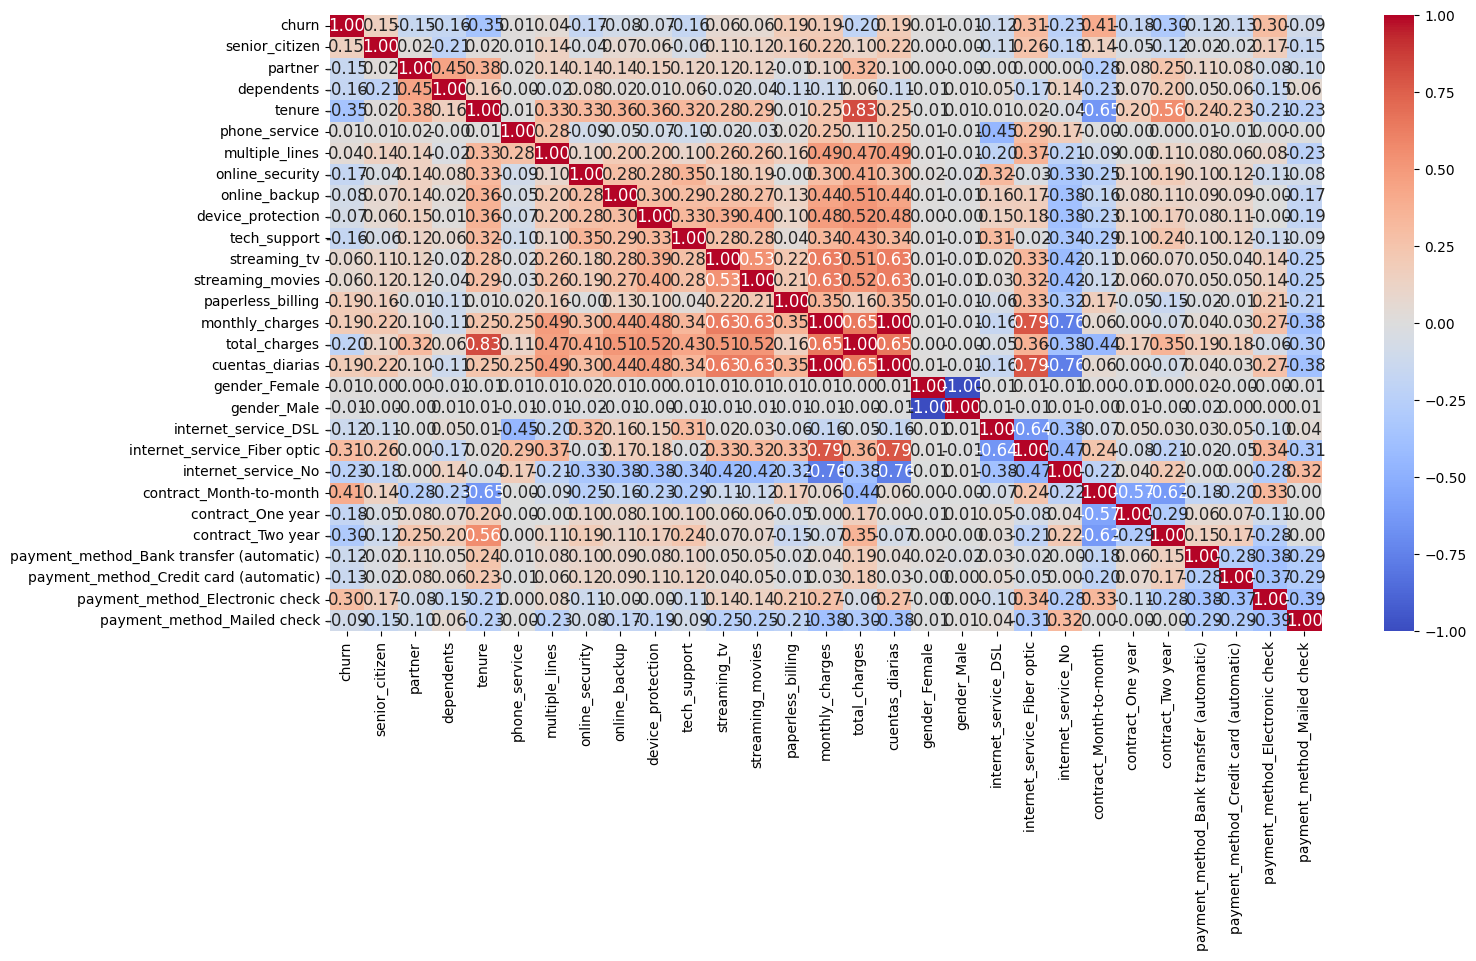

In [9]:
corr = df_encoded.corr()

plt.figure(figsize=(16,8))
sns.heatmap(corr,annot=True, cmap="coolwarm", fmt=".2f",annot_kws={"size":12})
plt.show()

### **Análisis dirigido**

In [10]:
df.columns

Index(['churn', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges',
       'cuentas_diarias'],
      dtype='str')

**Tenure x Churn (Tiempo de contrato por Cancelación)**

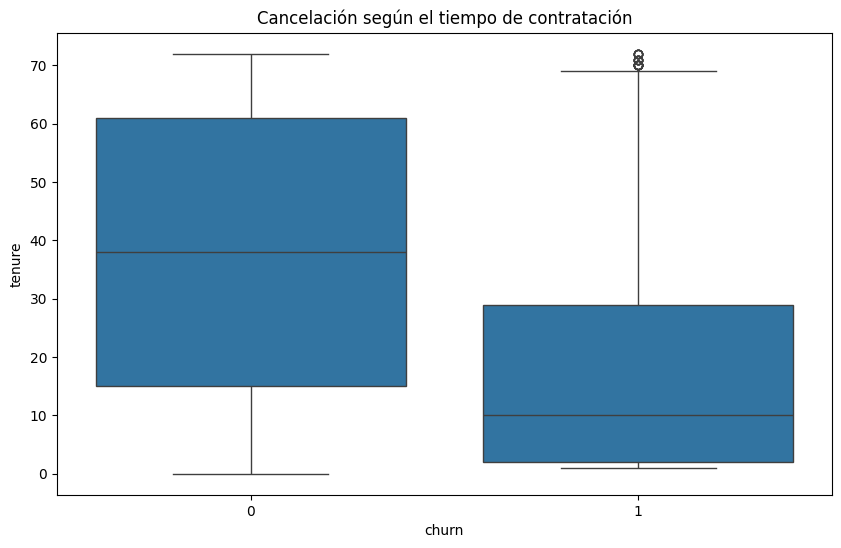

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(df, x='churn', y='tenure')

plt.title('Cancelación según el tiempo de contratación')
plt.show()

**Total Charges X Churn (Gasto total por cancelación)**

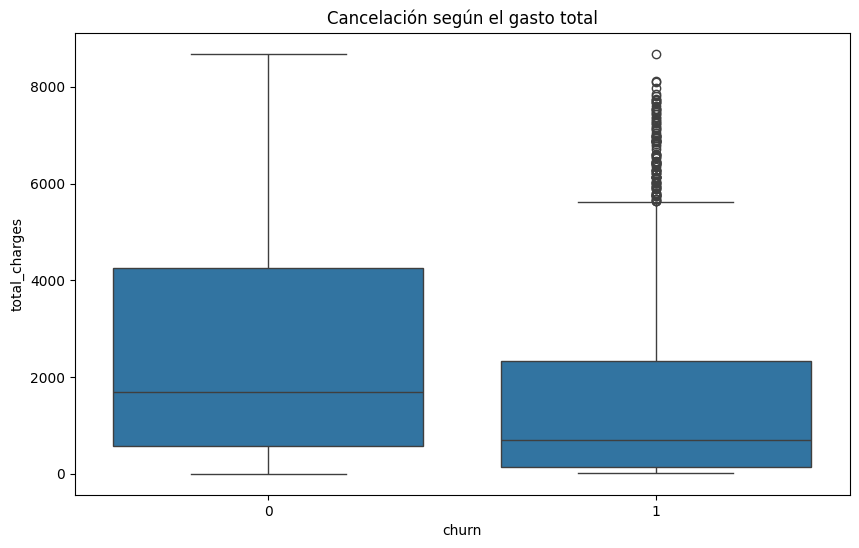

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(df, x='churn', y='total_charges')

plt.title('Cancelación según el gasto total')
plt.show()

### **Split**

In [17]:
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=TEST_SIZE, random_state = RANDOM_STATE)

### **Modelos predictivos**

In [19]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

In [20]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

### **Evaluación de los modelos**

In [22]:
# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

# Mostrar resultados
print("Exactitud (Accuracy):", accuracy)
print("Precisión:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Matriz de confusión:\n", conf_matrix)

Exactitud (Accuracy): 0.7955997161107168
Precisión: 0.7832826333261164
Recall: 0.7955997161107168
F1-score: 0.78448460793635
Matriz de confusión:
 [[942  94]
 [194 179]]


### **Análisis de importancia**

In [27]:
# Importancia de variables
importancias = rf.feature_importances_

features_name = df_encoded.columns.drop('churn')

df_importancia = pd.DataFrame({
    'Variable': features_name,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print(df_importancia)

                                    Variable  Importancia
14                             total_charges     0.150904
3                                     tenure     0.143329
13                           monthly_charges     0.105981
21                   contract_Month-to-month     0.104599
15                           cuentas_diarias     0.101212
26           payment_method_Electronic check     0.048724
19              internet_service_Fiber optic     0.046495
23                         contract_Two year     0.045587
6                            online_security     0.021770
22                         contract_One year     0.021544
20                       internet_service_No     0.018234
12                         paperless_billing     0.017840
9                               tech_support     0.014853
18                      internet_service_DSL     0.014741
1                                    partner     0.013949
7                              online_backup     0.013118
0             

## **INFORME FINAL**

El presente análisis tiene como objetivo identificar los principales factores que incluyen la cancelación de clientes (churn) utilizando modelos de Machine Learning. Para ello se entrenó un modelo de clasificación RandomForestClassifier y se evaluó su rendimiento mediante métricas como accuracy, precisión, recall, F1-score y matriz de confusión.

**Factores más influyentes en la cancelación**   

Variable y su importancia en la predicción:

**total_charges:** 0.1509  
**tenure:** 0.1433  
**monthly_charges:** 0.1060  
**contract_Month-to-month:** 0.1046 
**cuentas_diarias:**	0.1012   


El análisis del modelo indica que varios factores influyen significativamente en la cancelación de clientes. Entre los más importantes se encuentran la antigüedad del cliente (tenure), los cargos mensuales y totales, y el tipo de contrato. En general, los clientes con menor antigüedad y con cargos mensuales más elevados presentan mayor probabilidad de cancelar el servicio. Además, el tipo de contrato tiene un papel relevante, ya que los clientes con contratos mes a mes (Month-to-month) tienden a cancelar con mayor frecuencia, mientras que los contratos de mayor duración, como los de dos años, favorecen la permanencia. También se observa que el método de pago Electronic check está asociado con mayor cancelación en comparación con métodos automáticos, y que el servicio de internet por fibra óptica aparece como un factor relevante, posiblemente debido a sus mayores costos o a expectativas más altas por parte de los clientes respecto a la calidad del servicio.

**Recomendaciones**  

A partir de los factores identificados, se proponen las siguientes estrategias para reducir la cancelación de clientes:   
**(1)** incentivar contratos de mayor duración mediante descuentos, promociones o beneficios para clientes con permanencia anual o de dos años;  
**(2)** implementar programas de retención para nuevos clientes, incluyendo programas de bienvenida, soporte técnico prioritario y seguimiento durante los primeros meses;  
**(3)** optimizar los precios y planes de servicio ofreciendo opciones más flexibles o descuentos para clientes con cargos mensuales elevados; y  
**(4)** fomentar el uso de métodos de pago automáticos, como transferencias bancarias o tarjetas de crédito, para mejorar la estabilidad de los pagos y disminuir el riesgo de cancelación.

### **Conclusión**

El análisis realizado permitió identificar varios factores clave que influyen en la cancelación de clientes. Entre los más importantes se encuentran la antigüedad del cliente, los cargos mensuales, el monto total pagado y el tipo de contrato.

En particular, los clientes con contratos mensuales, menor antigüedad y cargos elevados presentan mayor probabilidad de cancelar el servicio.

La implementación de estrategias enfocadas en contratos de largo plazo, programas de retención temprana y optimización de planes de servicio puede contribuir significativamente a reducir la cancelación de clientes y mejorar la fidelización.